# PyTorch on images

We will use the CIFAR10 dataset. 

![CIFAR10](https://pytorch.org/tutorials/_images/cifar10.png)

It has the classes: 
`[‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’, ‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’]`
  
The images in CIFAR-10 are of size 3x32x32

i.e. 3-channel color images of 32x32 pixels in size.

## Let's load the libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
SEED = 42
torch.manual_seed(SEED)

## Let's load the data in the Dataset

This is the class which hold our samples.

PyTorch allow us to download some of the most famous datasets.
And to apply pre-processing to them (here loading them as tensor and normilizing them)

In [22]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


md = MyDataset(X=[1, 2, 3, 4, 5], y=[1, 2, 3, 4, 5])
md

In [23]:
len(md)

5

In [26]:
md[0]

(1, 1)

In [3]:
transform = transforms.Compose(
    [
		transforms.ToTensor(),
     	transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Mean of .5 for each channel, as well as Std of .5 for each channel
	]
)

trainset = torchvision.datasets.CIFAR10(
	root='./data', 
    train=True,
    download=True, 
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data', 
	train=False, 
	download=True, 
	transform=transform
)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170498071/170498071 [00:07<00:00, 23840250.66it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [4]:
len(trainset)

50000

In [5]:
len(testset)

10000

In [6]:
trainset[3]

(tensor([[[-0.7804, -0.7098, -0.7020,  ..., -0.4039, -0.3647, -0.3333],
          [-0.7412, -0.7333, -0.7490,  ..., -0.2549, -0.2471, -0.3333],
          [-0.6941, -0.6863, -0.5529,  ..., -0.2706, -0.1608, -0.2549],
          ...,
          [-0.3490, -0.3176, -0.3412,  ..., -0.2235, -0.2941, -0.3647],
          [-0.3098, -0.2941, -0.2706,  ..., -0.3725, -0.4039, -0.3569],
          [-0.2392, -0.2627, -0.2706,  ..., -0.5765, -0.5059, -0.4353]],
 
         [[-0.8039, -0.7333, -0.7255,  ..., -0.4745, -0.4353, -0.4039],
          [-0.7804, -0.7647, -0.7882,  ..., -0.3569, -0.3569, -0.4353],
          [-0.7490, -0.7412, -0.6078,  ..., -0.4039, -0.3020, -0.3961],
          ...,
          [-0.4275, -0.3961, -0.4196,  ..., -0.2706, -0.3412, -0.4118],
          [-0.4353, -0.4196, -0.3961,  ..., -0.4196, -0.4510, -0.4039],
          [-0.3882, -0.4118, -0.4118,  ..., -0.6314, -0.5608, -0.4902]],
 
         [[-0.9216, -0.8510, -0.8431,  ..., -0.6941, -0.6627, -0.6314],
          [-0.8980, -0.8902,

## Let's create the dataloader

The dataloader is used to load the data in batches.

It has many convenient features, like shuffling and loading the data in parallel.

In [7]:
batch_size = 4

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2
)

# Let's see some images

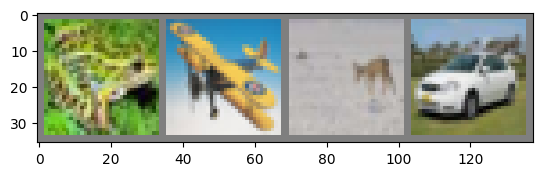

frog  plane deer  car  


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(" ".join(f"{classes[labels[j]]:5s}" for j in range(batch_size)))

# Defining our Neural Network

It's a Convolutional Neural Network (CNN)

In [9]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

## An image is just numbers for each channels

![Image as numbers](https://ruslanmv.com/assets/images/posts/2022-02-25-Introduction-to-Convolutional-Models/PAD.png)

## Convolutional layers

### Visualization

![CNN visualization](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*O06nY1U7zoP4vE5AZEnxKA.gif)

### Playground

[CNN Playground](https://setosa.io/ev/image-kernels/)

## MaxPooling

![MaxPooling](https://production-media.paperswithcode.com/methods/MaxpoolSample2.png)

In [10]:
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# Using the GPU

In [11]:
if torch.cuda.is_available():
    print(f"Cuda is available!")
    print(f"{torch.cuda.device_count() = }")
    device = torch.device("cuda")
else:
    print(f"Cuda is not available! Let's use the CPU")
    device = torch.device("cpu")

net.to(device)

Cuda is available!
torch.cuda.device_count() = 1


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

# Training the network

In [12]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        inputs = inputs.to(device) # /!\ We have to send the data to the GPU
        labels = labels.to(device) # /!\ We have to send the data to the GPU

        # forward + backward + optimize
        outputs = net(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        # zero the parameter gradients
        optimizer.zero_grad()
        
        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:  # print every 2000 mini-batches
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}")
            running_loss = 0.0

print("Finished Training")

[1,  2000] loss: 2.142
[1,  4000] loss: 1.830
[1,  6000] loss: 1.675
[1,  8000] loss: 1.570
[1, 10000] loss: 1.521
[1, 12000] loss: 1.446
[2,  2000] loss: 1.403
[2,  4000] loss: 1.360
[2,  6000] loss: 1.344
[2,  8000] loss: 1.337
[2, 10000] loss: 1.309
[2, 12000] loss: 1.280
Finished Training


# Let's save the model

In [34]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)


# Let's load the model

In [14]:
PATH = "./cifar_net.pt"
net = Net()
net.load_state_dict(torch.load(PATH))

net.to(device) # Send the model to the GPU

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

# Let's see some predictions

First the ground truth

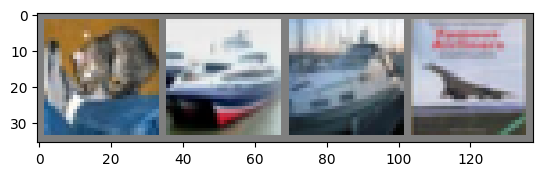

GroundTruth:  cat   ship  ship  plane


In [15]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print("GroundTruth: ", " ".join(f"{classes[labels[j]]:5s}" for j in range(4)))

Now the predicted values

In [16]:
outputs = net(images.to(device))
_, predicted = torch.max(outputs, 1)

print("Predicted: ", " ".join(f"{classes[predicted[j]]:5s}" for j in range(4)))

Predicted:  bird  ship  ship  ship 


not bad

# Let's evaluate the network

In [17]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, axis=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the network on the 10000 test images: {100 * correct // total} % for a total of {len(classes) = } classes")

Accuracy of the network on the 10000 test images: 54 % for a total of len(classes) = 10 classes


In [18]:
dataiter = iter(testloader)
images, labels = next(dataiter)

images.shape, labels.shape

(torch.Size([4, 3, 32, 32]), torch.Size([4]))

In [19]:
images = images.to(device)
net(images).shape

torch.Size([4, 10])